In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ford-car-price-prediction/ford.csv


# This is a project to predict the Ford car prices. 
Dataset - https://www.kaggle.com/datasets/adhurimquku/ford-car-price-prediction

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv( '/kaggle/input/ford-car-price-prediction/ford.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


**EDA (Exploratory Data Analysis)**

In [4]:
df.shape

(17966, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


Conclusions on seeing the data after running df.describe 
1. Year/Production Year can not be greater than the current year.

In [7]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

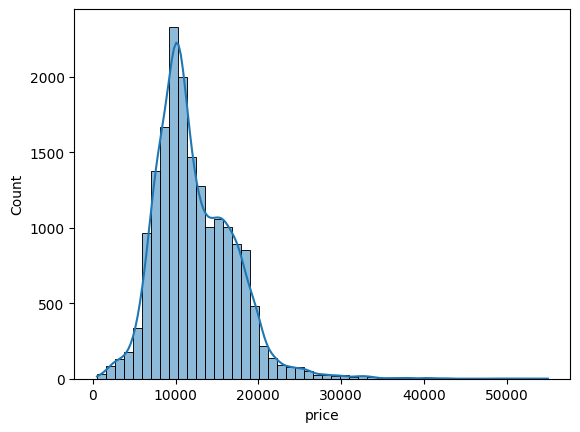

In [8]:
sns.histplot(x = df['price'], kde=True, bins=50)

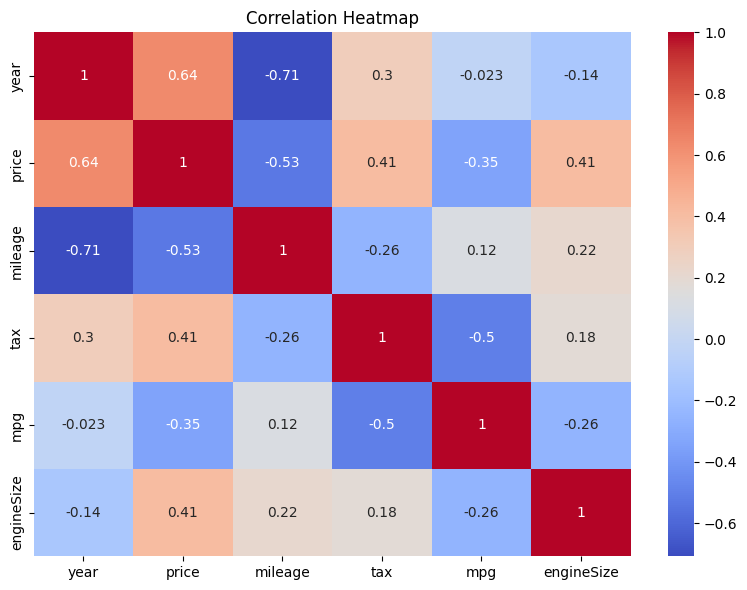

In [9]:
# Now we will see the correlation of numerical colums and charges

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='model'>

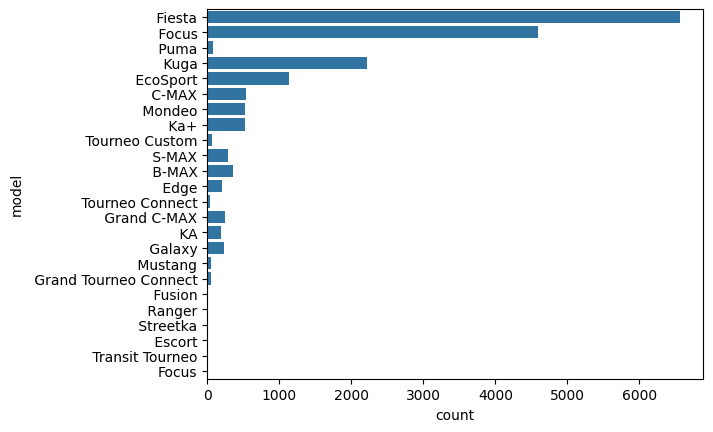

In [10]:
sns.countplot(df['model'])

<Axes: xlabel='count', ylabel='engineSize'>

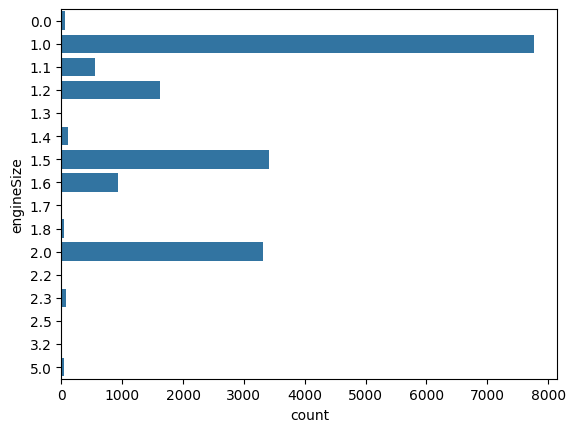

In [11]:
sns.countplot(y = df['engineSize'])

<Axes: xlabel='count', ylabel='fuelType'>

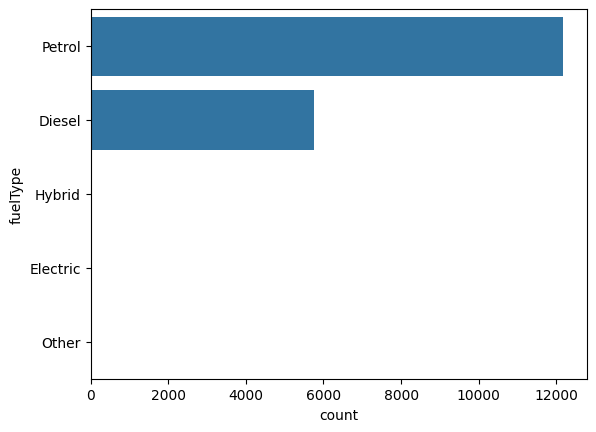

In [12]:
sns.countplot(df['fuelType'])

<Axes: xlabel='count', ylabel='transmission'>

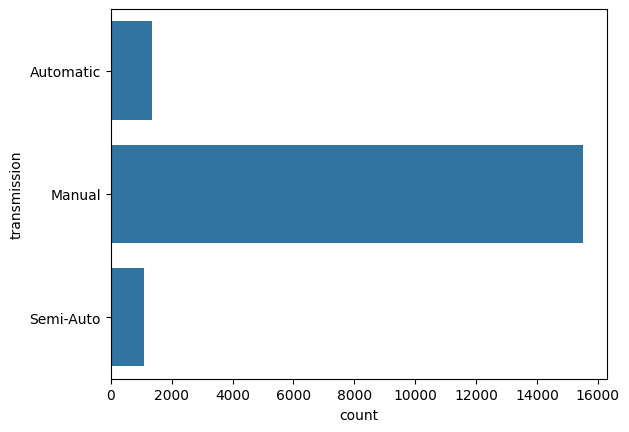

In [13]:
sns.countplot(df['transmission'])

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

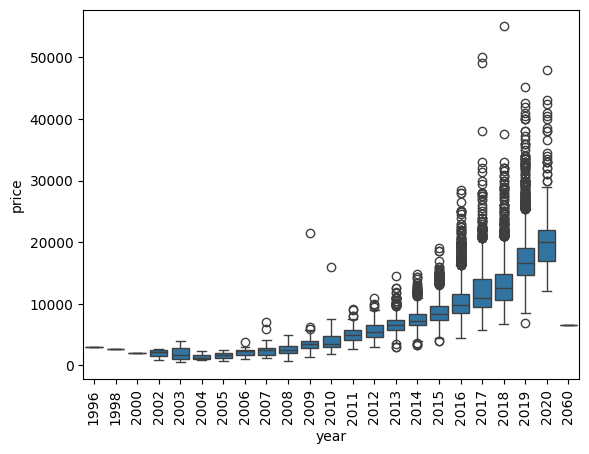

In [14]:
sns.boxplot(data=df, y='price', x='year')
plt.xticks(rotation=90)

In [15]:
# based on the above, i can say that 2060 is an outlier and the car prices are increasing as the years pass


In [16]:
df.columns


Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

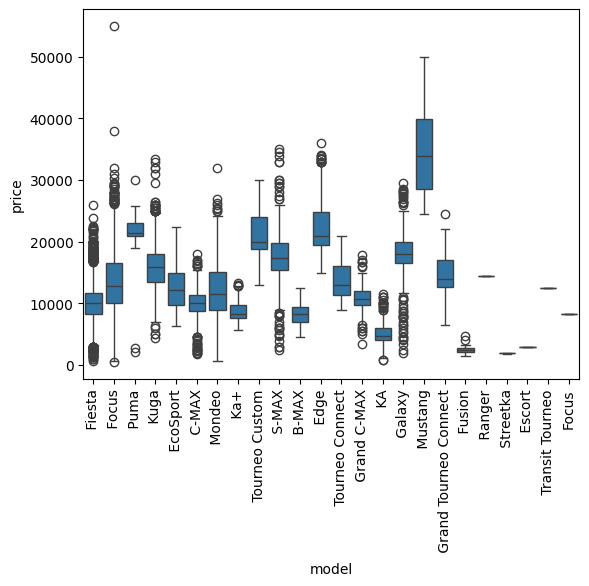

In [17]:
sns.boxplot(data = df, x='model', y='price')
plt.xticks(rotation = 90)

([0, 1, 2],
 [Text(0, 0, 'Automatic'), Text(1, 0, 'Manual'), Text(2, 0, 'Semi-Auto')])

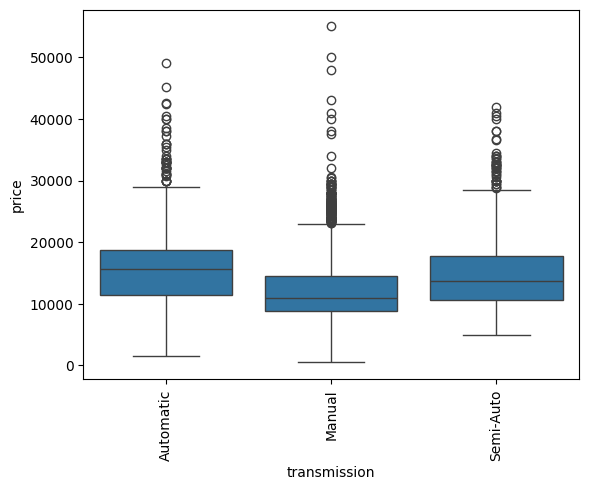

In [18]:
sns.boxplot(data = df, x='transmission', y='price')
plt.xticks(rotation = 90)

In [19]:
#seeing the above, the price's means are similar for each transmission, can't conclude much about the relation of the two


<Axes: xlabel='mileage', ylabel='price'>

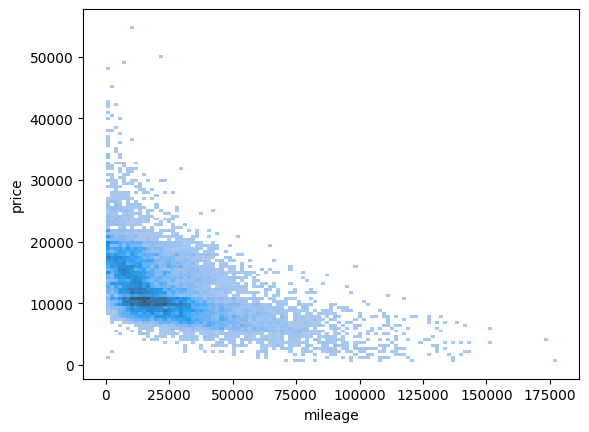

In [20]:
sns.histplot(x=df['mileage'], y=df['price'])

<Axes: xlabel='fuelType', ylabel='price'>

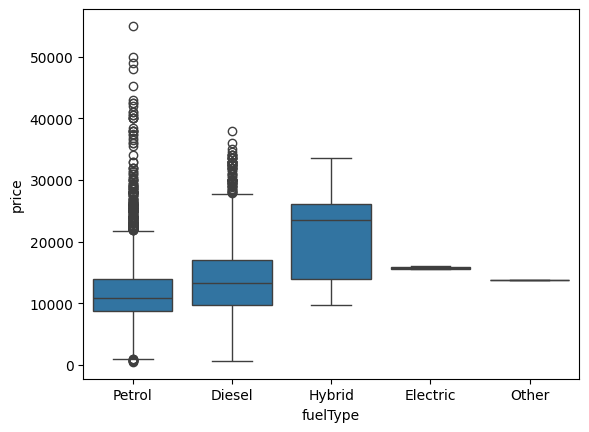

In [21]:
sns.boxplot(data=df, x='fuelType', y='price')

In [22]:
#petrol has a lot of outliers and 'electric' and 'other' have very low amount of data

<Axes: xlabel='engineSize', ylabel='price'>

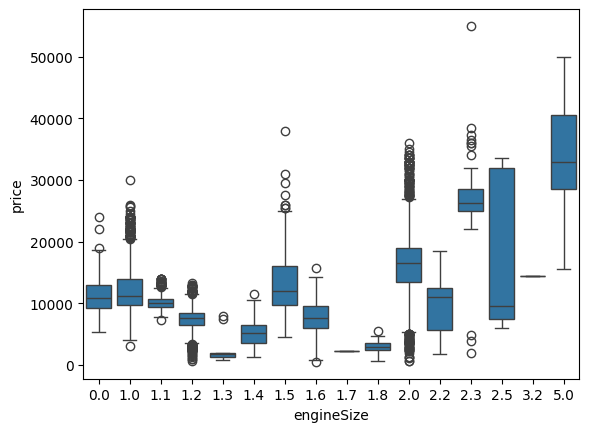

In [23]:
sns.boxplot(data=df, x='engineSize', y='price')

<Axes: xlabel='tax', ylabel='price'>

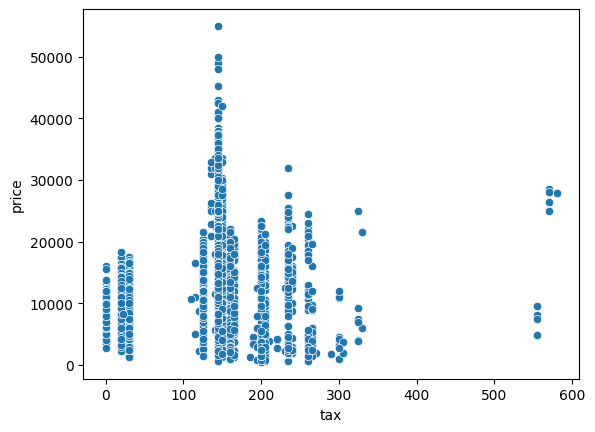

In [24]:
sns.scatterplot(data=df, x='tax', y='price')

In [25]:
# a lot of cars have tax aruond 100-200, but i cant see a pattern or relation here

<Axes: xlabel='mpg', ylabel='price'>

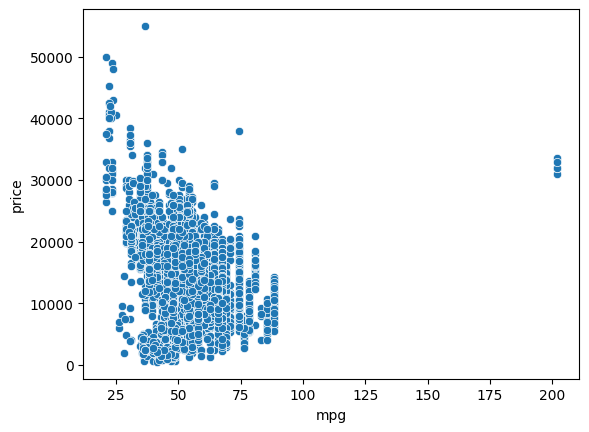

In [26]:
sns.scatterplot(x=df['mpg'],y=df['price'])

In [27]:
X = df.drop('price', axis=1)
y = df['price']

**Data cleaning + preprocessing**

In [28]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [29]:
X_encode_1 = pd.get_dummies(X, columns=['model', 'transmission', 'fuelType'], drop_first=True)
X_encode_1 = X_encode_1.astype('int')

In [30]:
X_encode_1.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [31]:
cols = ['model', 'transmission', 'fuelType']
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X_encode_label = X

for c in cols :
    X_encode_label[c] = label_encoder.fit_transform(X_encode_label[c])

In [32]:
X_encode_label

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [33]:
# now we have done label encoding and one hot encoding
# now we will check how the models will perform with these 2
# but first let's do standard scaling

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_cols = ['year',	'mileage',	'tax',	'mpg']
X_encode_1[numerical_cols] = scaler.fit_transform(X_encode_1[numerical_cols])

numerical_cols = X_encode_label.columns

X_encode_label[numerical_cols] = scaler.fit_transform(X_encode_label[numerical_cols])

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_encode_1, y,test_size=0.2, random_state=42)

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [38]:
y_predictions = model.predict(X_test)

In [39]:
r2 = r2_score(y_test, y_predictions)

In [40]:
r2

0.8464177711972798

In [41]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)) / (n-p-1) 
adjusted_r2

0.8449505624927862

In [42]:
# one hot endocoded model performs well as r2 and ajusted_r2 are close and high

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X_encode_label, y,test_size=0.2, random_state=42)

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_predictions = model.predict(X_test)

In [46]:
r2 = r2_score(y_test, y_predictions)
r2

0.7365884288851352

In [47]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)) / (n-p-1) 
adjusted_r2

0.7360006206371801

In [48]:
# one hot encoded model performs better than the label encoded model